# Step 3 Analysis — Reading the Judgments

The demo notebook ([`03_llm_judge.ipynb`](../demos/03_llm_judge.ipynb)) showed
single live judgments; this notebook analyzes the panel's verdicts at scale
and produces the final quiz.

**Prerequisites** — run the panel from the repo root first:

```bash
# 03-1: one run per judge model
for M in gpt-5.6-luna gpt-5.5-2026-04-23 gpt-5.4-mini-2026-03-17; do
  uv run python scripts/03-1_generate_judgments.py \
      --questions data/questions/questions_gemini-3.1-flash-lite.jsonl \
      --articles data/articles/guardian_articles.jsonl \
      --model $M --parallel
done

# 03-2: merge the per-model files into one tidy CSV
uv run python scripts/03-2_combine_judgments.py \
    --input-dir data/judgments --glob 'judgments_*.jsonl'
```

Those commands produce `data/judgments/judgments_<model>.jsonl` per judge and
the tidy `data/judgments/judgments_combined.csv` this notebook reads.

## 1. Loading the combined judgments


From here on we assume those two commands already ran. We just load the tidy
CSV — one row per (question × judge) — and analyze it:


In [1]:
import pandas as pd

df = pd.read_csv("../../data/judgments/judgments_combined.csv")
n_questions = df["question_id"].nunique()
n_judges = df["judge_model"].nunique()

print(f"{len(df)} judgments = {n_questions} questions x {n_judges} judges")
df.head(3)[["question_id", "judge_model", "faithful", "rationale"]]

546 judgments = 182 questions x 3 judges


,question_id,judge_model,faithful,rationale
0,gemini__australia-news/2026/jul/15/antisemitis...,gpt-5.4-mini-2026-03-17,True,The article explicitly says Davis said the sit...
1,gemini__australia-news/2026/jul/15/antisemitis...,gpt-5.5-2026-04-23,True,The article states that Davis said the situati...
2,gemini__australia-news/2026/jul/15/antisemitis...,gpt-5.6-luna,True,The article states that Davis said the situati...


## 2. How strict is each judge?

The selection script prints these numbers as text; in a notebook we can *see*
them. First: each judge's pass rate. If one judge is far stricter than the
others, the majority vote is quietly leaning on the other two.

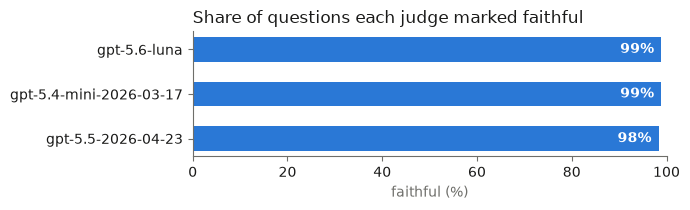

In [2]:
import matplotlib.pyplot as plt

from toolkit.plotting import BLUE, INK, MUTED, NEUTRAL, clean_axes

rates = (df.groupby("judge_model")["faithful"].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(7, 2.2))
bars = ax.barh(rates.index, rates.values, color=BLUE, height=0.55)
for bar, v in zip(bars, rates.values):
    ax.text(v - 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%",
            ha="right", va="center", color="white", fontweight="bold")
ax.set_xlim(0, 100)
ax.set_title("Share of questions each judge marked faithful", loc="left", color=INK)
ax.set_xlabel("faithful (%)", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 3. How often do the judges agree?

The vote only matters where judges disagree. This distribution shows how many
questions got 3, 2, 1, or 0 faithful votes — everything left of the 2-vote
line is filtered out:

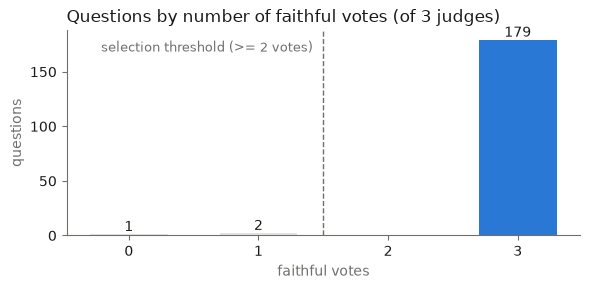

Unanimous verdicts: 99% of questions


In [3]:
votes = df.groupby("question_id")["faithful"].sum().astype(int)
dist = votes.value_counts().reindex(range(n_judges + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(6, 3))
colors = [BLUE if k >= 2 else NEUTRAL for k in dist.index]
bars = ax.bar([str(k) for k in dist.index], dist.values, color=colors, width=0.6)
for bar, v in zip(bars, dist.values):
    if v:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                ha="center", va="bottom", color=INK)
ax.axvline(1.5, color=MUTED, linestyle="--", linewidth=1)
ax.text(1.45, ax.get_ylim()[1] * 0.95, "selection threshold (>= 2 votes) ",
        ha="right", va="top", color=MUTED, fontsize=9)
ax.set_title("Questions by number of faithful votes (of 3 judges)", loc="left", color=INK)
ax.set_xlabel("faithful votes", color=MUTED)
ax.set_ylabel("questions", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

unanimous = ((votes == 0) | (votes == n_judges)).mean()
print(f"Unanimous verdicts: {unanimous:.0%} of questions")

## 4. The verdict matrix

Every verdict at once — judges on one axis, questions on the other. Vertical
white stripes are questions *someone* doubted; they're where you should go
read the rationales:

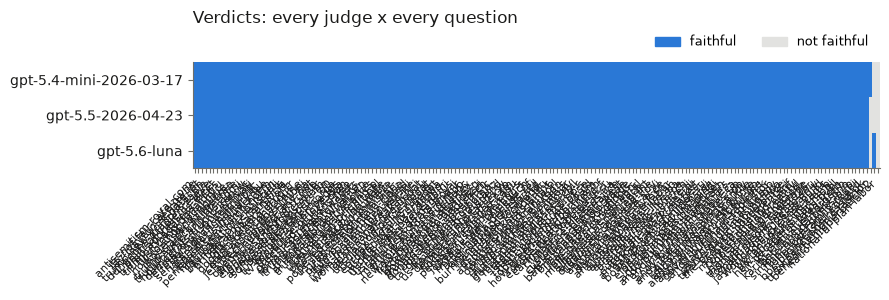

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

matrix = df.pivot_table(index="judge_model", columns="question_id",
                        values="faithful").astype(int)
matrix = matrix[matrix.sum().sort_values(ascending=False).index]  # passers first

fig, ax = plt.subplots(figsize=(9, 1.6 + 0.5 * len(matrix)))
ax.imshow(matrix.values, cmap=ListedColormap([NEUTRAL, BLUE]),
          aspect="auto", vmin=0, vmax=1)
ax.set_yticks(range(len(matrix.index)), matrix.index)
ax.set_xticks(range(len(matrix.columns)),
              [c.split("/")[-1][:22] for c in matrix.columns],
              rotation=45, ha="right", fontsize=8)
ax.set_title("Verdicts: every judge x every question", loc="left", color=INK, pad=28)
ax.legend(handles=[Patch(color=BLUE, label="faithful"),
                   Patch(color=NEUTRAL, label="not faithful")],
          loc="lower right", bbox_to_anchor=(1.0, 1.02), frameon=False, ncols=2, fontsize=9)
clean_axes(ax)
plt.tight_layout()
plt.show()

And the rationales behind every "not faithful" — the judges explain
themselves, which is what makes this filter auditable rather than a black
box:

In [9]:
fails = df[~df["faithful"]]
for qid, g in fails.groupby("question_id"):
    print(f"FAILED by {len(g)} judge(s): {qid}")
    for _, r in g.iterrows():
        print(f"  {r['judge_model']}: {r['rationale']}\n")

FAILED by 2 judge(s): gemini__world/2026/jul/16/target-of-monaco-bomb-blames-attack-on-ukrainian-spy-agency__q0
  gpt-5.4-mini-2026-03-17: The article says Anastasiia Berezovska was found dead near Kyiv, and separately says the forest where she was allegedly taken and killed was near the village of Yuriv. The marked answer C is not directly supported as the location where her body was discovered; D is the closer match to the text.

  gpt-5.5-2026-04-23: The article says Berezovska was “found dead near Kyiv” and separately says prosecutors allege she was taken to a forest near Yuriv “where she was killed.” It does not directly state that her body was discovered near Yuriv, so the marked answer relies on an inference or conflates the killing location with the discovery location.



## 5. The passing rule and the seeded draw

Selection is two lines of pandas: a question passes when **>= 2 distinct
judges** marked it faithful...

In [5]:
passing = votes[votes >= 2]
print(f"judged {n_questions} -> passing {len(passing)} "
      f"({len(passing) / n_questions:.0%})")

judged 182 -> passing 179 (98%)


...and the final quiz is a **seeded random sample** of the passers. Seeding
matters for research: `random.Random(42).sample(...)` means anyone re-running
the pipeline on the same data draws the *same* questions — reproducibility
for free.

The script wraps both, plus the join back to full question records:

```bash
uv run python scripts/03-3_select_questions.py \
    --input data/judgments/judgments_combined.csv \
    --questions data/questions/questions_gemini-3.1-flash-lite.jsonl
```

In [6]:
!cd ../.. && uv run python scripts/03-3_select_questions.py \
    --input data/judgments/judgments_combined.csv \
    --questions data/questions/questions_gemini-3.1-flash-lite.jsonl 2>&1

2026-07-26 12:49:00,576 - select_questions - INFO - 179 of 182 judged questions (98%) pass (>= 2 of 3 models: faithful)
2026-07-26 12:49:00,577 - select_questions - INFO - Per-judge pass rates (182 judgments each):
2026-07-26 12:49:00,577 - select_questions - INFO -   gpt-5.4-mini-2026-03-17    faithful  99%
2026-07-26 12:49:00,578 - select_questions - INFO -   gpt-5.5-2026-04-23         faithful  98%
2026-07-26 12:49:00,578 - select_questions - INFO -   gpt-5.6-luna               faithful  99%
2026-07-26 12:49:00,578 - select_questions - INFO - Failure breakdown: 7 of 546 judgments marked faithful=False
2026-07-26 12:49:00,579 - select_questions - INFO - Agreement (questions by number of judges passing them):
2026-07-26 12:49:00,579 - select_questions - INFO -   3/3 judges: 179 questions
2026-07-26 12:49:00,579 - select_questions - INFO -   2/3 judges: 0 questions
2026-07-26 12:49:00,579 - select_questions - INFO -   1/3 judges: 2 questions
2026-07-26 12:49:00,579 - select_questions -

In [7]:
from toolkit.utils import load_jsonl

selected = load_jsonl("../../data/questions/selected_questions.jsonl")
print(f"{len(selected)} questions in the final quiz. One of them:\n")
q = selected[0]
print(q["question"])
for letter, option in zip("ABCD", q["options"]):
    mark = "*" if letter == q["correct_letter"] else " "
    print(f"  {mark}{letter}. {option}")
print(f"\n(passed {q['n_models_passing']} of 3 judges)")

100 questions in the final quiz. One of them:

Which company conducted the AI detection review of Pope Leo XIV's collection of speeches and writings, Maps of Hope?
   A. Breaking News Australia
  *B. Proudly Human
   C. Australian Catholic University
   D. The Vatican Publishing House

(passed 3 of 3 judges)


In [8]:
selected_df = pd.DataFrame(selected)
selected_df.head()

,id,article_id,question_index,provider,model,question,options,correct_letter,explanation,generated_at,n_models_passing
0,gemini__world/2026/jul/21/pope-leo-speech-huma...,world/2026/jul/21/pope-leo-speech-human-not-ai...,0,gemini,gemini-3.1-flash-lite,Which company conducted the AI detection revie...,"[Breaking News Australia, Proudly Human, Austr...",B,"The article states that Proudly Human, an Aust...",2026-07-26T16:27:22.020792+00:00,3
1,gemini__commentisfree/2026/jul/17/tourists-wor...,commentisfree/2026/jul/17/tourists-world-china...,0,gemini,gemini-3.1-flash-lite,What proportion of foreign national entries in...,"[20.6%, 50.0%, 77.7%, 85.3%]",C,The article states that in the first half of 2...,2026-07-26T16:27:31.239364+00:00,3
2,gemini__australia-news/2026/jul/16/albanese-ai...,australia-news/2026/jul/16/albanese-ai-plan-te...,0,gemini,gemini-3.1-flash-lite,When does Anthony Albanese intend to push parl...,"[By the end of this year, In the middle of 202...",C,The article states that after a meeting of the...,2026-07-26T16:27:39.166230+00:00,3
3,gemini__politics/2026/jul/17/andy-burnham-team...,politics/2026/jul/17/andy-burnham-team-reshape...,0,gemini,gemini-3.1-flash-lite,"According to the article, how much does the Of...","[£2 billion, £6 billion, £10 billion, £15 bill...",B,The article states that the government indemni...,2026-07-26T16:27:31.136243+00:00,3
4,gemini__lifeandstyle/ng-interactive/2026/jul/2...,lifeandstyle/ng-interactive/2026/jul/25/long-l...,0,gemini,gemini-3.1-flash-lite,What led Avtar Singh to finally discover his m...,"[A DNA match on Ancestry.com, An appeal he rec...",C,"Avtar typed a prompt into ChatGPT, which sugge...",2026-07-26T16:27:10.725269+00:00,3


## 6. The map

| This notebook | Where it lives |
|---|---|
| §1 tidy CSV | `scripts/03-2_combine_judgments.py` |
| §2–4 analysis | figures here; the same stats print from `scripts/03-3_select_questions.py` (add `--show-failures` for §4's rationales) |
| §5 selection | `scripts/03-3_select_questions.py` (`--n`, `--seed`, `--min-passing`) |

---

### Next up: Step 4

We now have a vetted, reproducible quiz. Time to put the models to the test:
the same LLMs answering **closed-book**, **with web search**, and via
**multi-agent debate** — continue with
[`04a_closed_book.ipynb`](../demos/04a_closed_book.ipynb).
